# OW Yellow Caps — Notebook 2: Univariate EDA

**Client:** OW Yellow Caps  
**Data:** NYC TLC Yellow Taxi · Jan–Mar 2025 (post-cleaning)  
**Purpose:** One-variable-at-a-time exploration of all key fields.

## Coverage (per TOR §6.1)
- Trip volume over time (daily, weekly, monthly)
- trip_distance distribution
- trip_duration distribution
- fare_amount distribution
- total_amount distribution
- passenger_count distribution
- payment_type frequencies
- RatecodeID frequencies
- VendorID frequencies
- Congestion and CBD fee distributions

**Visualization principles** from the course Data Visualisation slides:
- Choose the right chart type for each data scale (nominal, ordinal, continuous)
- Label axes, add titles, avoid chartjunk
- Use colour purposefully (single-hue for single variables, highlight exceptions)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

CLEAN_PATH = 'yellow_taxi_clean.parquet'

df = pd.read_parquet(CLEAN_PATH)
print(f'Loaded: {len(df):,} rows × {df.shape[1]} columns')
print('Columns:', df.columns.tolist())

Loaded: 10,448,657 rows × 33 columns
Columns: ['trip_id', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'source_month', 'flag_reason', 'trip_duration_min', 'pickup_hour', 'pickup_dow', 'pickup_dow_name', 'pickup_date', 'pickup_month', 'pickup_week', 'is_weekend', 'is_post_cbd', 'speed_mph']


---
## 1. Trip Volume Over Time

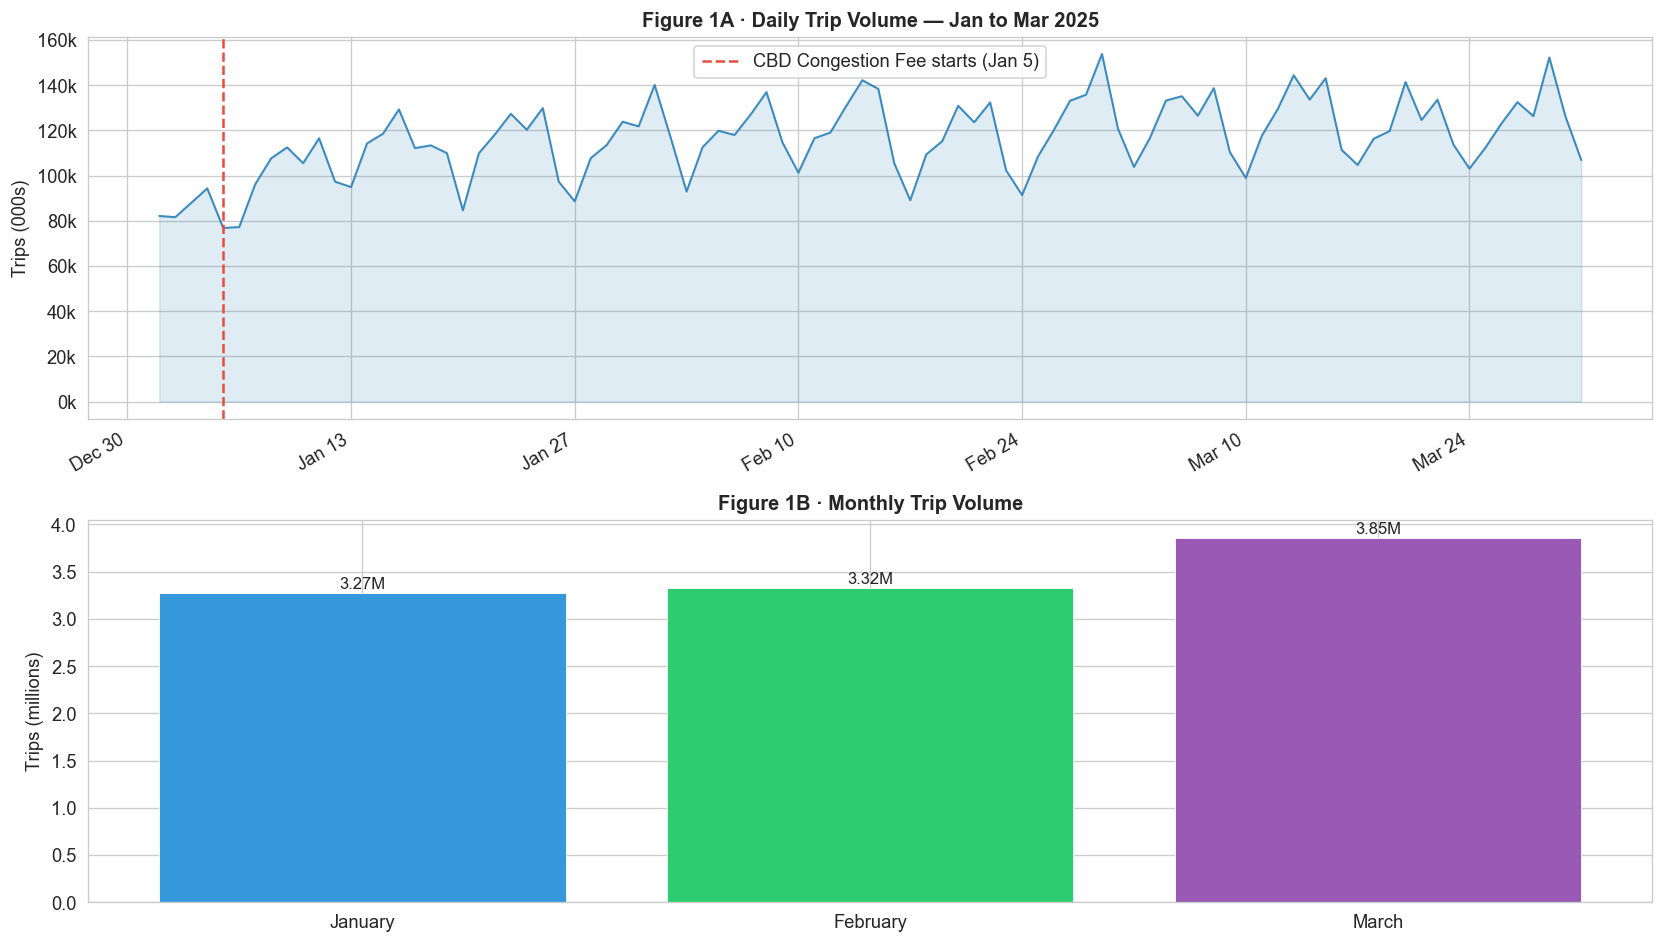

Monthly totals:
 pickup_month  trip_count month_name
            1     3270695    January
            2     3324279   February
            3     3853683      March


In [5]:
# ── Daily trip volume ─────────────────────────────────────────────────────
daily = df.groupby('pickup_date').size().reset_index(name='trip_count')
daily['pickup_date'] = pd.to_datetime(daily['pickup_date'])
daily = daily.sort_values('pickup_date')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily line chart
ax = axes[0]
ax.plot(daily.pickup_date, daily.trip_count / 1000,
        color='#2980b9', linewidth=1.2, alpha=0.9)
ax.fill_between(daily.pickup_date, daily.trip_count / 1000,
                alpha=0.15, color='#2980b9')
ax.axvline(pd.Timestamp('2025-01-05'), color='#e74c3c', linestyle='--',
           lw=1.5, label='CBD Congestion Fee starts (Jan 5)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('Trips (000s)')
ax.set_title('Figure 1A · Daily Trip Volume — Jan to Mar 2025')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

# Monthly bar chart
ax2 = axes[1]
monthly = df.groupby('pickup_month').size().reset_index(name='trip_count')
month_names = {1: 'January', 2: 'February', 3: 'March'}
monthly['month_name'] = monthly.pickup_month.map(month_names)
bars = ax2.bar(monthly.month_name, monthly.trip_count / 1e6,
               color=['#3498db', '#2ecc71', '#9b59b6'],
               edgecolor='white', linewidth=0.5)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}M', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Trips (millions)')
ax2.set_title('Figure 1B · Monthly Trip Volume')

plt.tight_layout()
plt.show()

print('Monthly totals:')
print(monthly.to_string(index=False))

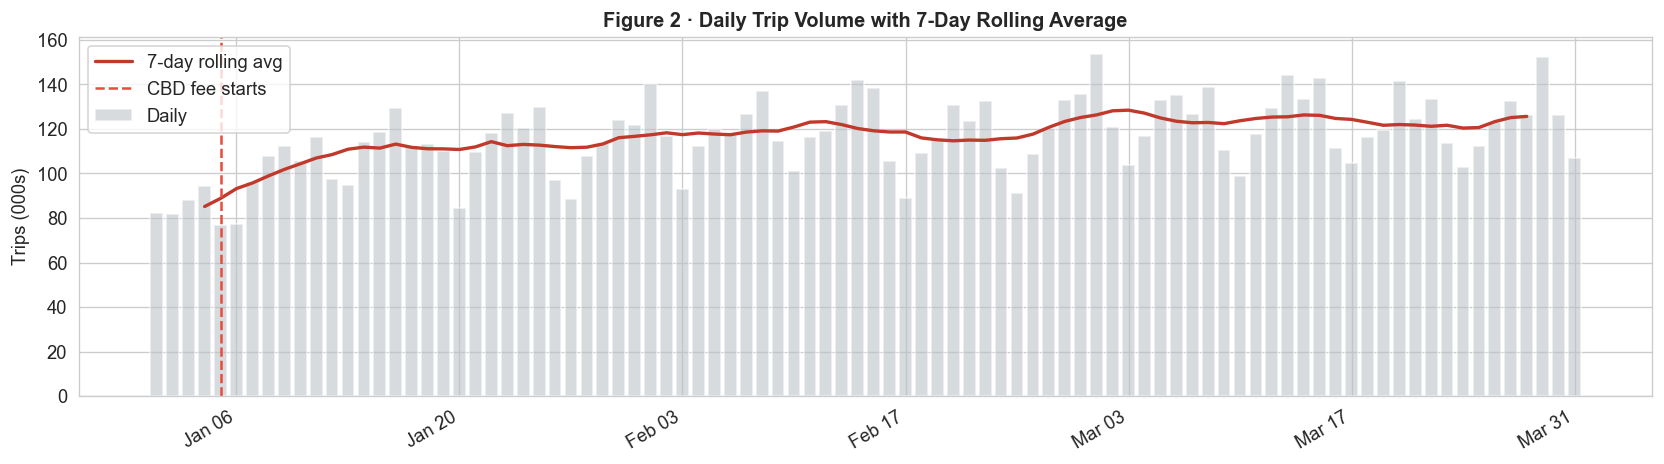

In [7]:
# ── Weekly volume (7-day rolling average) ────────────────────────────────
daily_ts = daily.set_index('pickup_date')['trip_count']
rolling7 = daily_ts.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_ts.index, daily_ts / 1000, color='#bdc3c7', alpha=0.6, label='Daily')
ax.plot(rolling7.index, rolling7 / 1000, color='#c0392b', lw=2, label='7-day rolling avg')
ax.axvline(pd.Timestamp('2025-01-05'), color='#e74c3c', linestyle='--',
           lw=1.5, label='CBD fee starts')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('Trips (000s)')
ax.set_title('Figure 2 · Daily Trip Volume with 7-Day Rolling Average')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Trip Distance Distribution

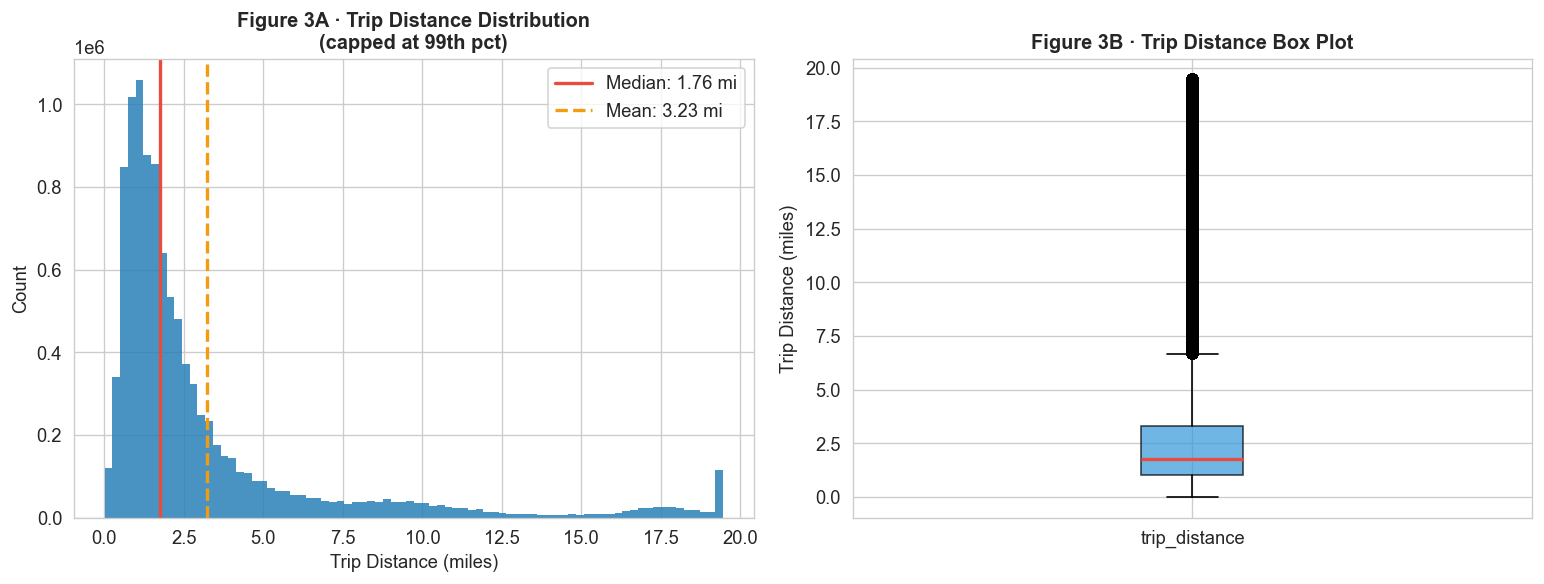

Trip Distance Statistics:
count    1.044866e+07
mean     3.227000e+00
std      4.135000e+00
min      1.000000e-02
25%      1.040000e+00
50%      1.760000e+00
75%      3.300000e+00
max      1.993000e+02
Name: trip_distance, dtype: float64


In [8]:
# Cap at 99th percentile for readability; extreme outliers already discussed in cleaning
dist_cap = df.trip_distance.quantile(0.99)
dist_data = df.trip_distance.clip(upper=dist_cap)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(dist_data, bins=80, color='#2980b9', edgecolor='none', alpha=0.85)
axes[0].axvline(df.trip_distance.median(), color='#e74c3c', lw=2,
                label=f'Median: {df.trip_distance.median():.2f} mi')
axes[0].axvline(df.trip_distance.mean(), color='#f39c12', lw=2, linestyle='--',
                label=f'Mean: {df.trip_distance.mean():.2f} mi')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Count')
axes[0].set_title('Figure 3A · Trip Distance Distribution\n(capped at 99th pct)')
axes[0].legend()

# Box plot
axes[1].boxplot(dist_data.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='#e74c3c', linewidth=2))
axes[1].set_ylabel('Trip Distance (miles)')
axes[1].set_xticklabels(['trip_distance'])
axes[1].set_title('Figure 3B · Trip Distance Box Plot')

plt.tight_layout()
plt.show()

print('Trip Distance Statistics:')
print(df.trip_distance.describe().round(3))

---
## 3. Trip Duration Distribution

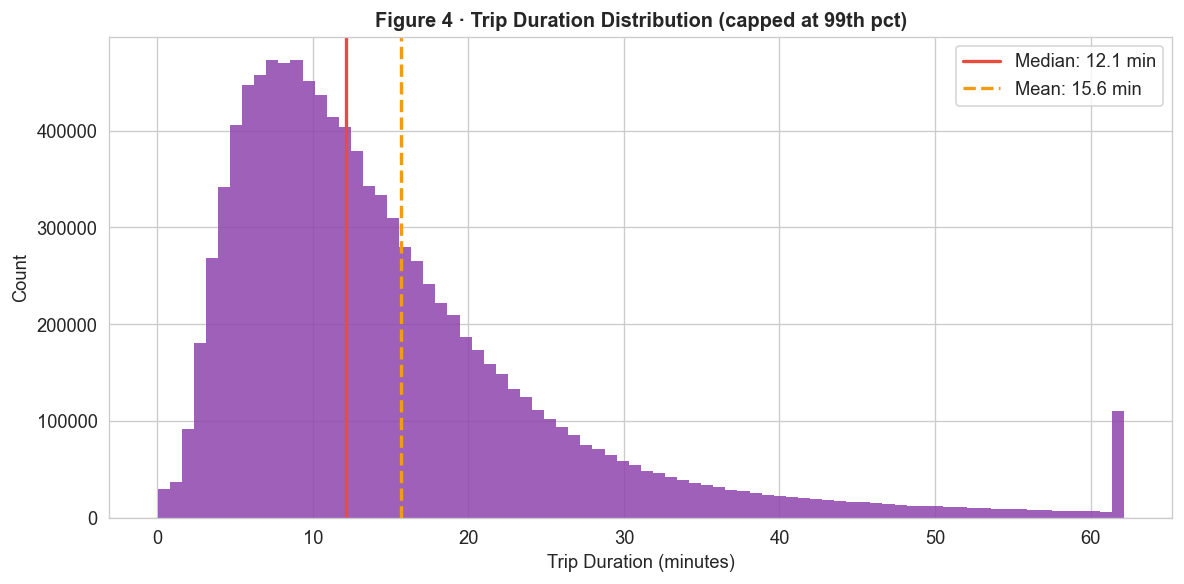

Trip Duration Statistics (minutes):
count    10448657.00
mean           15.64
std            27.43
min             0.02
25%             7.60
50%            12.12
75%            18.97
max          8564.67
Name: trip_duration_min, dtype: float64


In [10]:
dur_cap = df.trip_duration_min.quantile(0.99)
dur_data = df.trip_duration_min.clip(upper=dur_cap)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dur_data, bins=80, color='#8e44ad', edgecolor='none', alpha=0.85)
ax.axvline(df.trip_duration_min.median(), color='#e74c3c', lw=2,
           label=f'Median: {df.trip_duration_min.median():.1f} min')
ax.axvline(df.trip_duration_min.mean(), color='#f39c12', lw=2, linestyle='--',
           label=f'Mean: {df.trip_duration_min.mean():.1f} min')
ax.set_xlabel('Trip Duration (minutes)')
ax.set_ylabel('Count')
ax.set_title('Figure 4 · Trip Duration Distribution (capped at 99th pct)')
ax.legend()
plt.tight_layout()
plt.show()

print('Trip Duration Statistics (minutes):')
print(df.trip_duration_min.describe().round(2))

---
## 4. Fare Amount & Total Amount

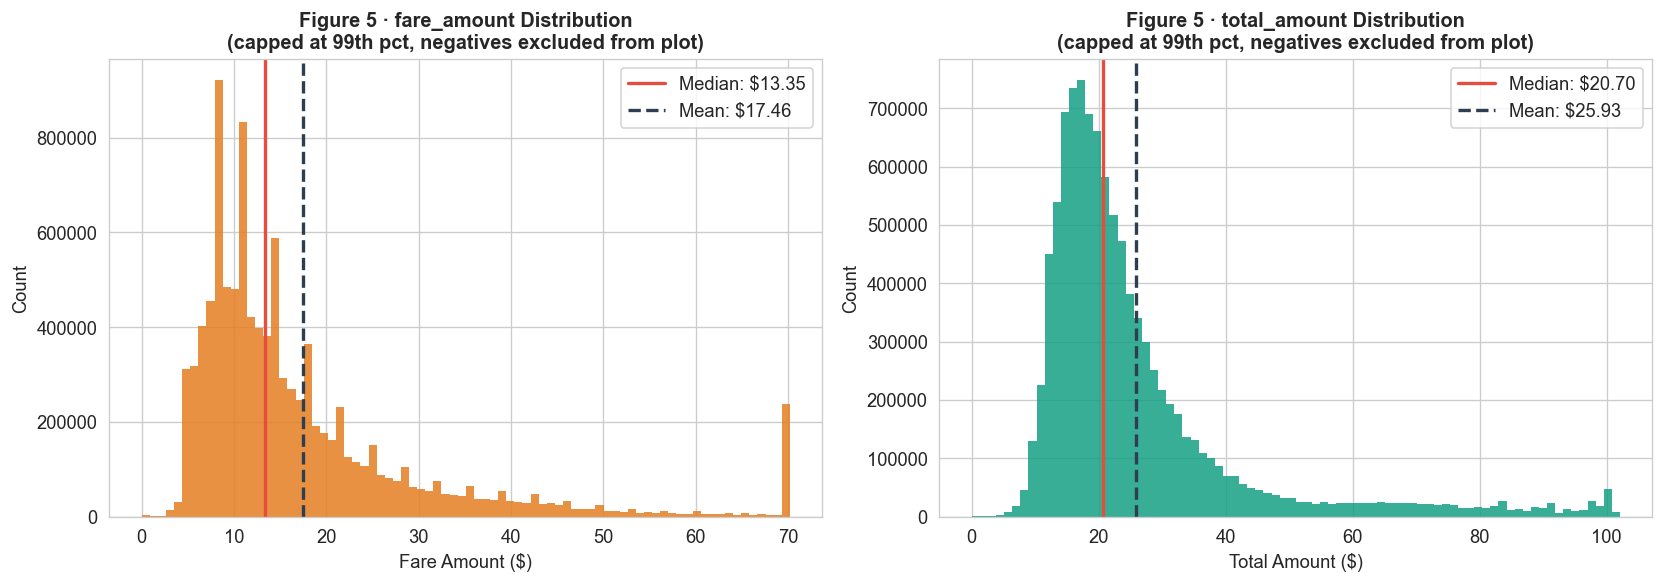

Fare Amount Statistics:
count    10177848.00
mean           17.46
std            13.33
min             0.00
25%             9.30
50%            13.35
75%            20.50
max            70.20
Name: fare_amount, dtype: float64

Total Amount Statistics:
count    10177848.00
mean           25.93
std            16.86
min             0.00
25%            16.02
50%            20.70
75%            28.55
max           102.11
Name: total_amount, dtype: float64


In [18]:
fare_cap  = df.fare_amount.quantile(0.99)
total_cap = df.total_amount.quantile(0.99)

df = df[(df.fare_amount >= 0) & (df.total_amount >= 0)]
df = df[(df.fare_amount <= fare_cap) & (df.total_amount <= total_cap)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, cap, color, label in [
    (axes[0], 'fare_amount',  fare_cap,  '#e67e22', 'Fare Amount ($)'),
    (axes[1], 'total_amount', total_cap, '#16a085', 'Total Amount ($)')
]:
    data = df[col].clip(lower=0, upper=cap)
    ax.hist(data, bins=80, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df[col].median(), color='#e74c3c', lw=2,
               label=f'Median: ${df[col].median():.2f}')
    ax.axvline(df[col].mean(), color='#2c3e50', lw=2, linestyle='--',
               label=f'Mean: ${df[col].mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'Figure 5 · {col} Distribution\n(capped at 99th pct, negatives excluded from plot)')
    ax.legend()

plt.tight_layout()
plt.show()

print('Fare Amount Statistics:')
print(df.fare_amount.describe().round(2))
print('\nTotal Amount Statistics:')
print(df.total_amount.describe().round(2))

---
## 5. Passenger Count

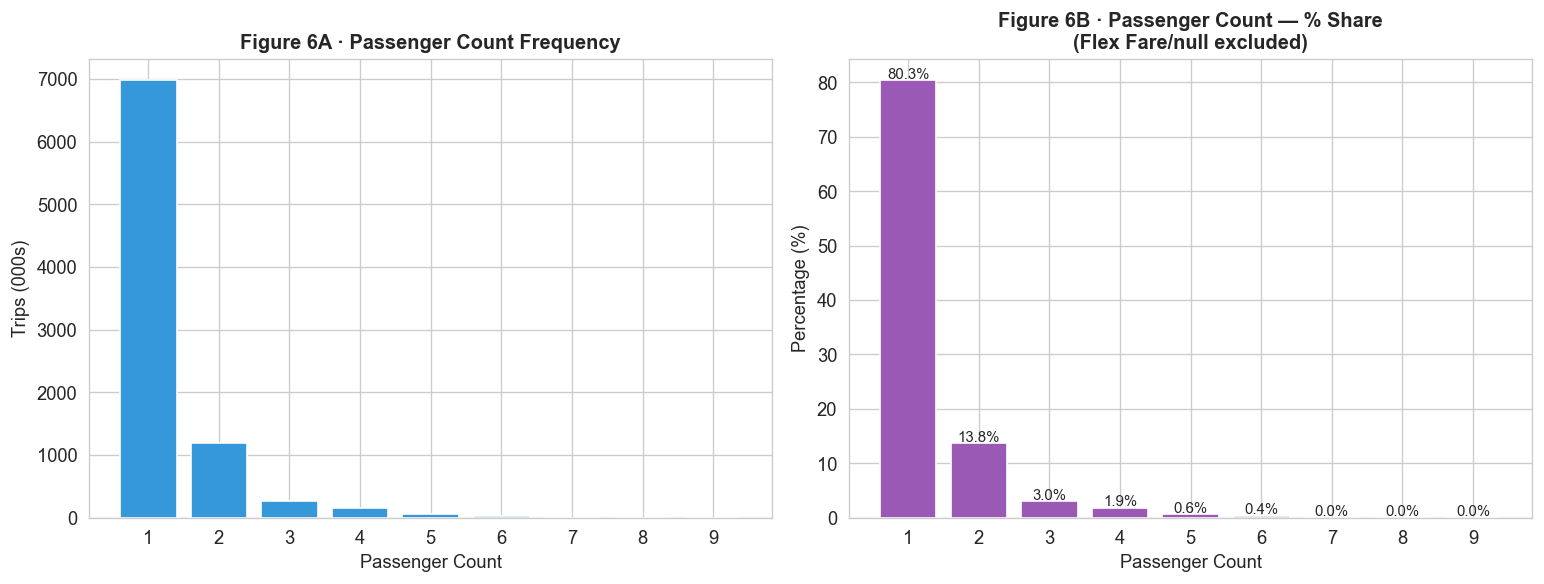

Passenger Count Distribution (non-null rows):
                   count    pct
passenger_count                
1                6975048  80.35
2                1195341  13.77
3                 263287   3.03
4                 161854   1.86
5                  52678   0.61
6                  32751   0.38
7                      5   0.00
8                     16   0.00
9                      5   0.00


In [14]:
# passenger_count is null for Flex Fare (payment_type=0); analyse non-null only
pax_data = df.passenger_count.dropna().astype(int)
pax_counts = pax_data.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(pax_counts.index.astype(str), pax_counts.values / 1000,
            color='#3498db', edgecolor='white')
axes[0].set_xlabel('Passenger Count')
axes[0].set_ylabel('Trips (000s)')
axes[0].set_title('Figure 6A · Passenger Count Frequency')

axes[1].bar(pax_counts.index.astype(str), pax_counts.values / pax_counts.sum() * 100,
            color='#9b59b6', edgecolor='white')
for i, (idx, val) in enumerate(pax_counts.items()):
    pct = val / pax_counts.sum() * 100
    axes[1].text(i, pct + 0.3, f'{pct:.1f}%', ha='center', fontsize=9)
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Figure 6B · Passenger Count — % Share\n(Flex Fare/null excluded)')

plt.tight_layout()
plt.show()

print('Passenger Count Distribution (non-null rows):')
print(pax_counts.to_frame('count').assign(pct=(pax_counts / pax_counts.sum() * 100).round(2)))

---
## 6. Payment Type

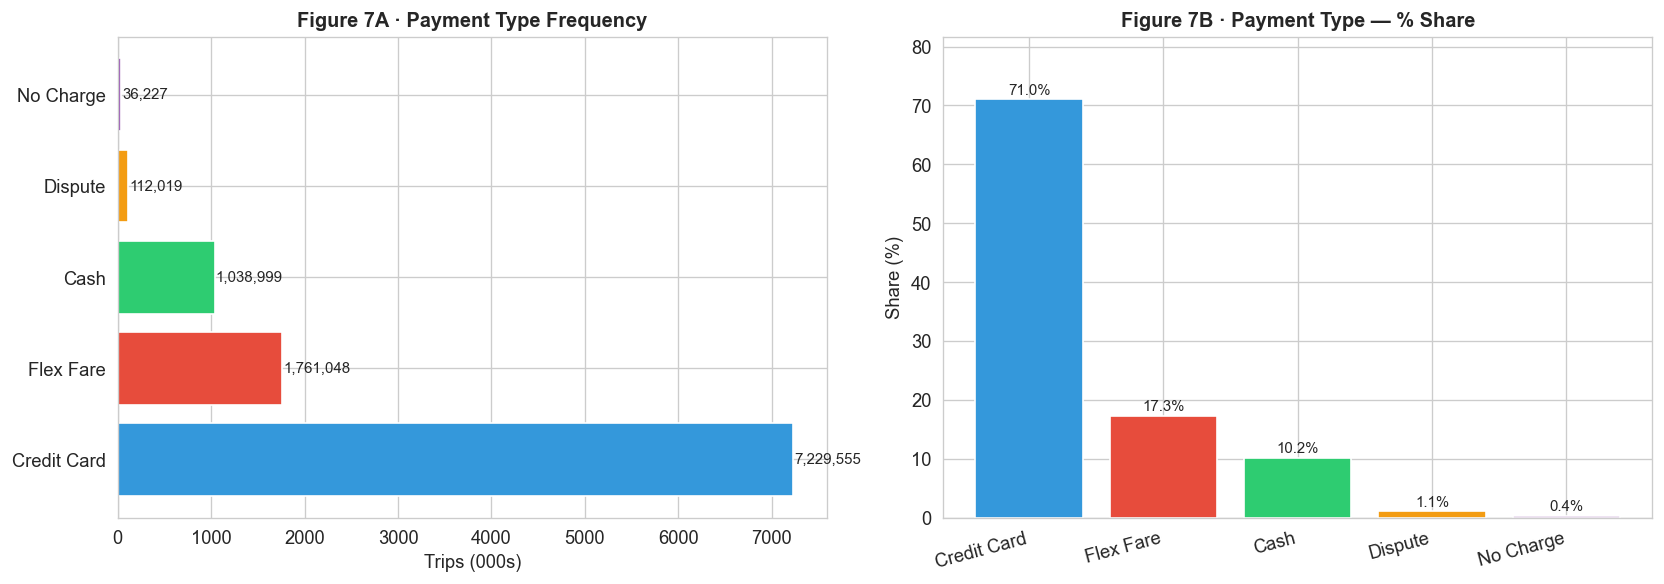

In [20]:
PT_LABELS = {0: 'Flex Fare', 1: 'Credit Card', 2: 'Cash',
             3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}

pt_counts = df.payment_type.map(PT_LABELS).value_counts()
pt_pct = pt_counts / pt_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal bar — raw counts
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6', '#1abc9c']
axes[0].barh(pt_counts.index, pt_counts.values / 1000,
             color=colors[:len(pt_counts)], edgecolor='white')
for i, v in enumerate(pt_counts.values):
    axes[0].text(v / 1000 + 10, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Trips (000s)')
axes[0].set_title('Figure 7A · Payment Type Frequency')

# Vertical bar — percentage share (replaces pie chart)
bars = axes[1].bar(pt_pct.index, pt_pct.values,
                   color=colors[:len(pt_pct)], edgecolor='white')
for bar, pct in zip(bars, pt_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Share (%)')
axes[1].set_title('Figure 7B · Payment Type — % Share')
axes[1].set_ylim(0, pt_pct.max() * 1.15)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

---
## 7. Rate Code Distribution

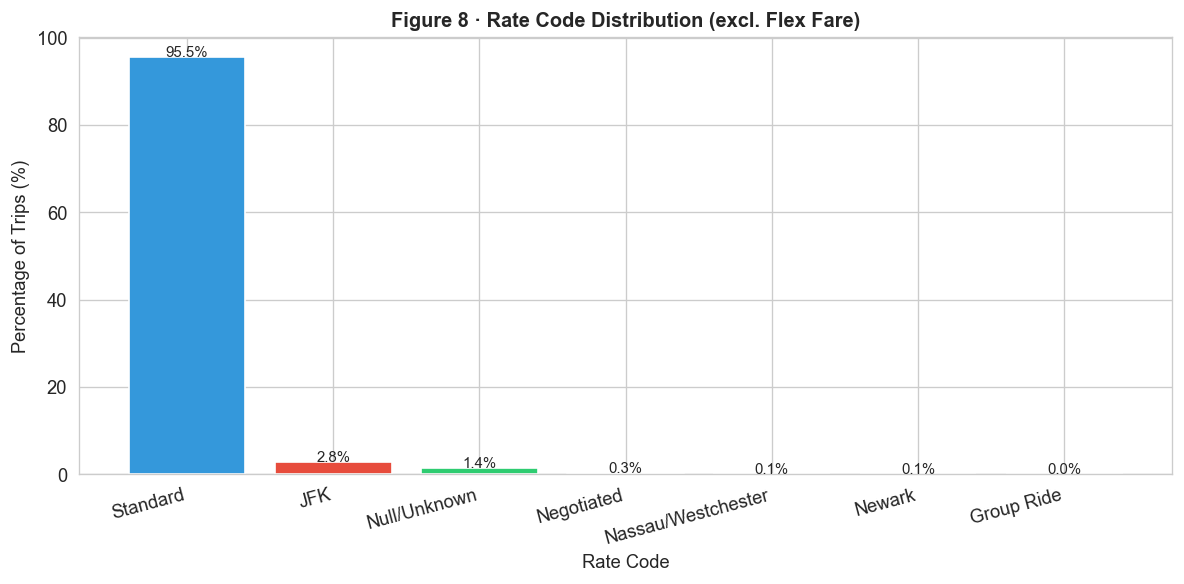


Rate code counts (excl. Flex Fare):
                      count    pct
RatecodeID                        
Standard            8034510  95.46
JFK                  231816   2.75
Null/Unknown         116172   1.38
Negotiated            22918   0.27
Nassau/Westchester     6197   0.07
Newark                 5180   0.06
Group Ride                7   0.00


In [22]:
RATE_LABELS = {1.0: 'Standard', 2.0: 'JFK', 3.0: 'Newark',
               4.0: 'Nassau/Westchester', 5.0: 'Negotiated',
               6.0: 'Group Ride', 99.0: 'Null/Unknown'}

rate_data = df[df.payment_type != 0]  # exclude Flex Fare (no RatecodeID)
rate_counts = rate_data.RatecodeID.map(RATE_LABELS).value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(rate_counts.index, rate_counts.values / rate_counts.sum() * 100,
              color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#95a5a6'])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Rate Code')
ax.set_ylabel('Percentage of Trips (%)')
ax.set_title('Figure 8 · Rate Code Distribution (excl. Flex Fare)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print('\nRate code counts (excl. Flex Fare):')
print(rate_counts.to_frame().assign(pct=(rate_counts/rate_counts.sum()*100).round(2)))

---
## 8. Vendor ID Distribution

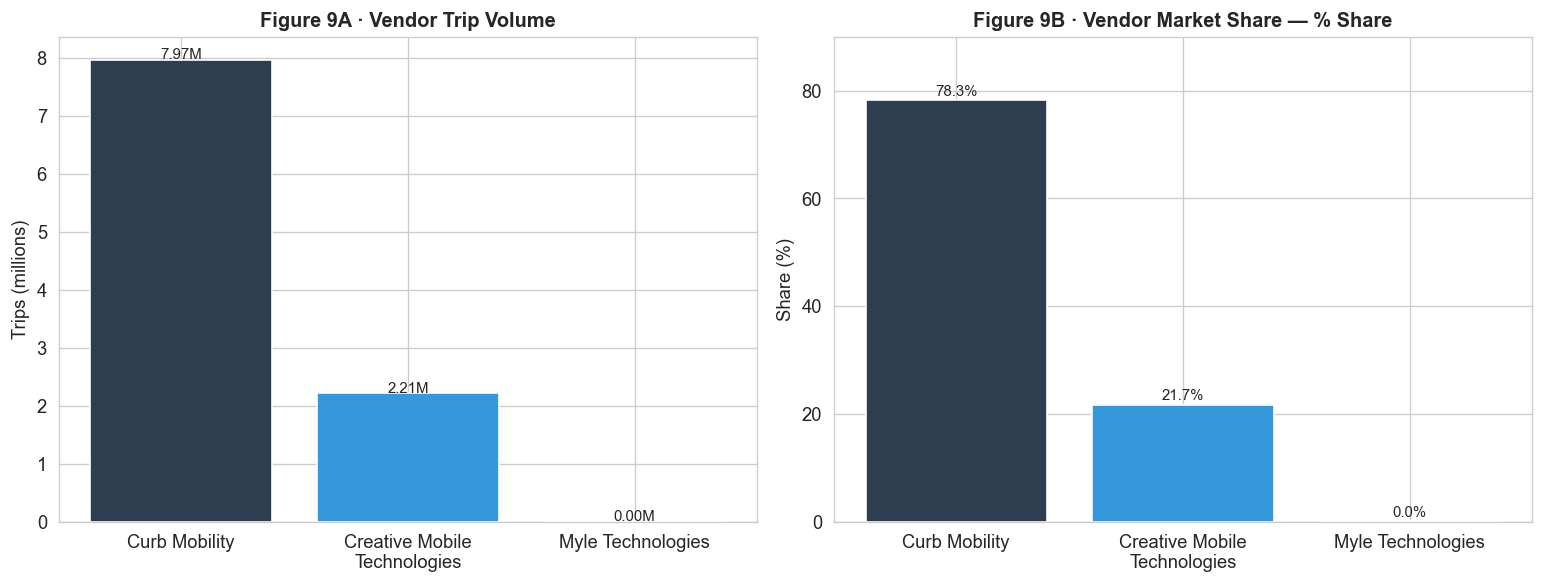

In [24]:
VENDOR_LABELS = {1: 'Creative Mobile\nTechnologies',
                 2: 'Curb Mobility',
                 6: 'Myle Technologies',
                 7: 'Helix'}

vendor_counts = df.VendorID.map(VENDOR_LABELS).value_counts()
vendor_pct = vendor_counts / vendor_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Vertical bar — raw counts
colors = ['#2c3e50', '#3498db', '#e74c3c', '#f39c12']
bars = axes[0].bar(vendor_counts.index, vendor_counts.values / 1e6,
                   color=colors[:len(vendor_counts)], edgecolor='white')
for bar, v in zip(bars, vendor_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{v/1e6:.2f}M', ha='center', fontsize=9)
axes[0].set_ylabel('Trips (millions)')
axes[0].set_title('Figure 9A · Vendor Trip Volume')

# Vertical bar — percentage share (replaces pie chart)
bars2 = axes[1].bar(vendor_pct.index, vendor_pct.values,
                    color=colors[:len(vendor_pct)], edgecolor='white')
for bar, pct in zip(bars2, vendor_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Share (%)')
axes[1].set_title('Figure 9B · Vendor Market Share — % Share')
axes[1].set_ylim(0, vendor_pct.max() * 1.15)

plt.tight_layout()
plt.show()

---
## 9. Tip Amount, Congestion & CBD Fee

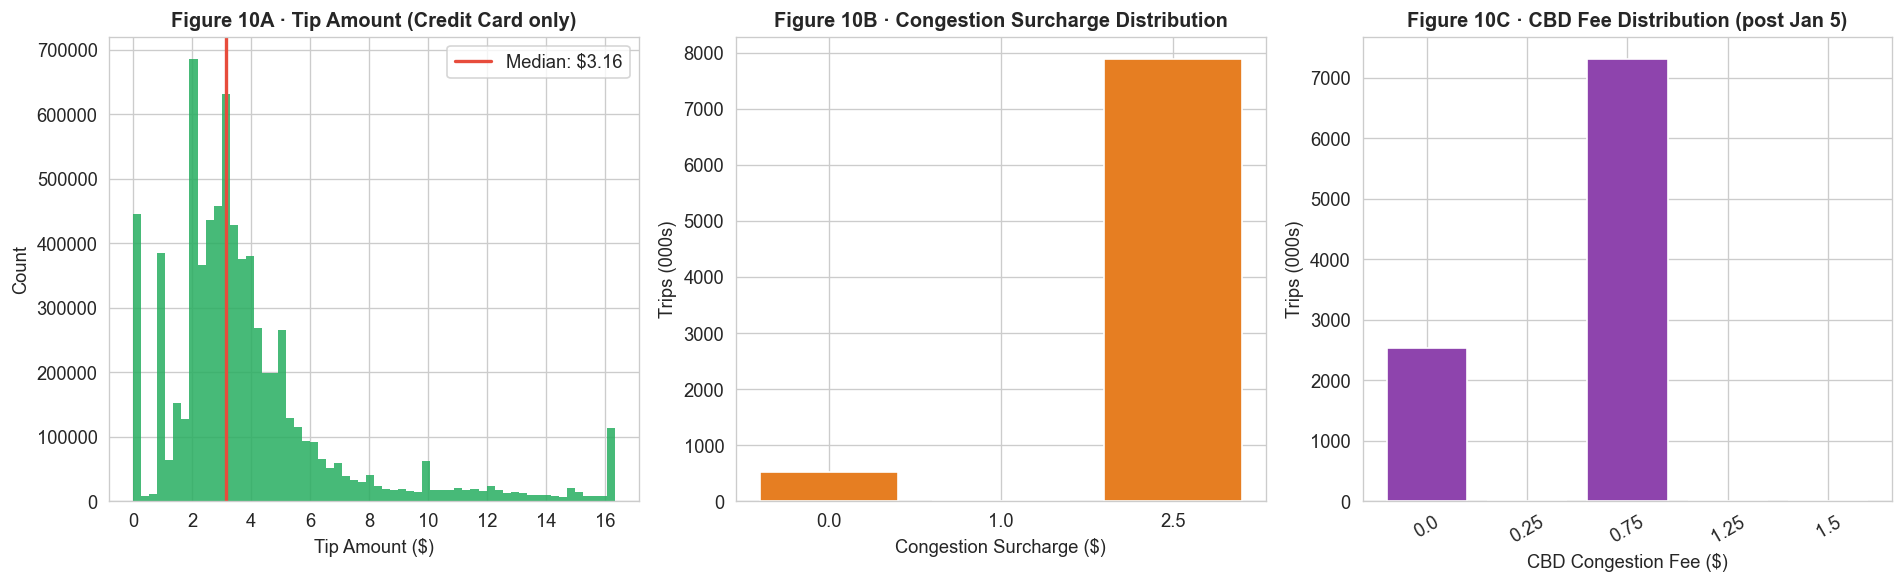

In [25]:
# Tip amount (credit card only — auto-populated)
tip_cc = df[df.payment_type == 1]['tip_amount']
tip_cap = tip_cc.quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tip distribution
axes[0].hist(tip_cc.clip(upper=tip_cap), bins=60,
             color='#27ae60', edgecolor='none', alpha=0.85)
axes[0].axvline(tip_cc.median(), color='#e74c3c', lw=2, label=f'Median: ${tip_cc.median():.2f}')
axes[0].set_xlabel('Tip Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Figure 10A · Tip Amount (Credit Card only)')
axes[0].legend()

# Congestion surcharge
cong_counts = df.congestion_surcharge.value_counts().sort_index()
axes[1].bar([str(x) for x in cong_counts.index], cong_counts.values / 1000,
            color='#e67e22', edgecolor='white')
axes[1].set_xlabel('Congestion Surcharge ($)')
axes[1].set_ylabel('Trips (000s)')
axes[1].set_title('Figure 10B · Congestion Surcharge Distribution')

# CBD congestion fee (post Jan 5 only)
cbd_post = df[df.is_post_cbd]['cbd_congestion_fee']
cbd_counts = cbd_post.value_counts().sort_index().head(10)
axes[2].bar([str(x) for x in cbd_counts.index], cbd_counts.values / 1000,
            color='#8e44ad', edgecolor='white')
axes[2].set_xlabel('CBD Congestion Fee ($)')
axes[2].set_ylabel('Trips (000s)')
axes[2].set_title('Figure 10C · CBD Fee Distribution (post Jan 5)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

---
## 10. Summary Statistics Table

=== Univariate Summary Statistics Table ===
                           count    mean     std   min    25%    50%    75%    95%    99%      max  skewness  kurtosis
trip_distance         10177848.0   3.004   3.590  0.01   1.04   1.74   3.19  10.56  18.30   199.30     2.930    14.264
trip_duration_min     10177848.0  15.206  27.026  0.02   7.57  12.02  18.58  35.05  58.05  8564.67    48.713  4025.127
fare_amount           10177848.0  17.456  13.330  0.00   9.30  13.35  20.50  45.70  70.00    70.20     2.172     5.056
total_amount          10177848.0  25.935  16.865  0.00  16.02  20.70  28.55  66.54  96.44   102.11     2.386     6.036
tip_amount            10177848.0   2.859   3.241  0.00   0.00   2.47   3.99   9.50  16.19    90.00     2.297    10.696
congestion_surcharge   8416800.0   2.346   0.602  0.00   2.50   2.50   2.50   2.50   2.50     2.50    -3.641    11.258
cbd_congestion_fee    10177848.0   0.539   0.337  0.00   0.00   0.75   0.75   0.75   0.75     1.50    -0.972    -1.055
pass

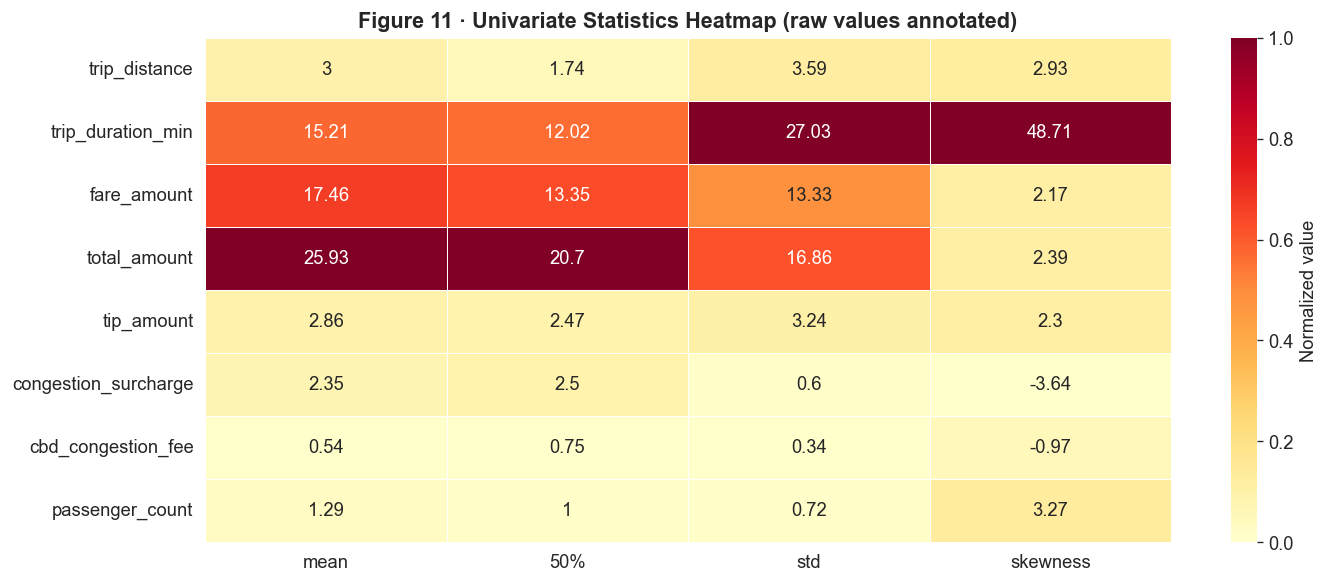

In [26]:
summary_cols = ['trip_distance', 'trip_duration_min', 'fare_amount',
                'total_amount', 'tip_amount', 'congestion_surcharge',
                'cbd_congestion_fee', 'passenger_count']

stats = df[summary_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T
stats['skewness'] = df[summary_cols].skew().round(3)
stats['kurtosis'] = df[summary_cols].kurtosis().round(3)
print('=== Univariate Summary Statistics Table ===')
print(stats.round(3).to_string())

# Visualize as heatmap of normalized stats
fig, ax = plt.subplots(figsize=(12, 5))
norm_stats = stats[['mean', '50%', 'std', 'skewness']].copy()
# Normalize per column for heatmap
norm = (norm_stats - norm_stats.min()) / (norm_stats.max() - norm_stats.min() + 1e-9)
sns.heatmap(norm, annot=norm_stats.round(2), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalized value'})
ax.set_title('Figure 11 · Univariate Statistics Heatmap (raw values annotated)', fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# ── KPI summary card ──────────────────────────────────────────────────────
n = len(df)
print('=' * 50)
print('    OW YELLOW CAPS — UNIVARIATE KPI SNAPSHOT')
print('=' * 50)
print(f'Total Clean Trips (Jan–Mar 2025):  {n:>12,}')
print(f'Median Trip Distance (miles):      {df.trip_distance.median():>12.2f}')
print(f'Median Trip Duration (min):        {df.trip_duration_min.median():>12.1f}')
print(f'Median Fare Amount ($):            {df.fare_amount.median():>12.2f}')
print(f'Median Total Amount ($):           {df.total_amount.median():>12.2f}')
print(f'Avg Tip (CC trips only, $):        {df[df.payment_type==1].tip_amount.mean():>12.2f}')
print(f'Credit Card share:                 {100*(df.payment_type==1).mean():>11.1f}%')
print(f'Cash share:                        {100*(df.payment_type==2).mean():>11.1f}%')
print(f'Flex Fare share:                   {100*(df.payment_type==0).mean():>11.1f}%')
print(f'Solo riders (pax=1, non-Flex):     {100*((df.passenger_count==1)&(df.payment_type!=0)).mean():>11.1f}%')
print('=' * 50)

    OW YELLOW CAPS — UNIVARIATE KPI SNAPSHOT
Total Clean Trips (Jan–Mar 2025):    10,177,848
Median Trip Distance (miles):              1.74
Median Trip Duration (min):                12.0
Median Fare Amount ($):                   13.35
Median Total Amount ($):                  20.70
Avg Tip (CC trips only, $):                3.92
Credit Card share:                        71.0%
Cash share:                               10.2%
Flex Fare share:                          17.3%
Solo riders (pax=1, non-Flex):            66.6%
